In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_no_maxpooling import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.5).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
#CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

Antal utan m-komponent i träningsdatan: 29837
Antal med m-komponent i träningsdatan: 2553


In [2]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Totalt antal utan m-komponent i K-fold poolen: 18848
Totalt antal med m-komponent i K-fold poolen: 2692
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
Epoch   0 | train: 1.1415 | val: 0.6703 | acc: 89.18% | AUC: 0.665  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_no_max_pooling_fold1.pth
Epoch   1 | train: 0.6088 | val: 0.5701 | acc: 89.28% | AUC: 0.767  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_no_max_pooling_fold1.pth
Epoch   2 | train: 0.4968 | val: 0.4802 | acc: 90.67% | AUC: 0.825  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_no_max_pooling_fold1.pth
Epoch   3 | train: 0.4520 | val: 0.4611 | acc: 90.90% | AUC: 0.843  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_no_max_pooling_fold1.pth
Epoch   4 | train: 0.4390 | val: 0.4363 | acc: 83.75% | AUC: 0.858  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_model_no_max_pooling_fold1.pth
Epoch   5 | t

,fold,train_loss,val_loss,val_accuracy,val_auc
0,1,0.120641,0.183286,93.871866,0.980699
1,2,0.080260,0.126108,95.636026,0.989117
2,3,0.116733,0.189849,95.631970,0.974596
3,4,0.129489,0.216539,94.243268,0.972250
4,5,0.314642,0.390060,87.325905,0.894976
5,6,0.098751,0.164239,94.705063,0.979708
6,7,0.093481,0.165577,95.494659,0.976949
7,8,0.171522,0.274590,89.498141,0.960782
8,9,0.144649,0.202347,95.125348,0.970609
9,10,0.093540,0.199826,94.428969,0.974765


              precision    recall  f1-score   support

     Negativ       0.99      0.98      0.98      7146
     Positiv       0.78      0.89      0.83       586

    accuracy                           0.97      7732
   macro avg       0.88      0.93      0.91      7732
weighted avg       0.97      0.97      0.97      7732

[[6995  151]
 [  65  521]]
AUC: 0.983659561806457
Accuracy:  97.21%
FN-rate:   11.09%  (farliga missade fall)
FP-rate:   2.11%  (onödiga larm)
Sensitivitet:   88.91%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   97.89%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9837


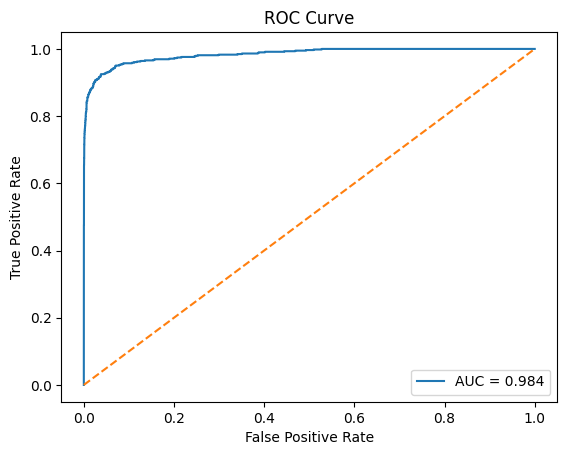

In [2]:
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = CNN.predict(test_rows)
_ = evaluate(result,threshold=0.5,proportion=70)